# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Devilia Dwi Candra
- **Email:** deviliadcandra@gmail.com
- **ID Dicoding:** deviliadc

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada jam berapa rata-rata konsentrasi polutan PM2.5 dan NO2 mencapai puncaknya di seluruh stasiun pemantau sepanjang tahun 2013–2017, dan bagaimana polanya pada jam sibuk (rush hour) pagi (07.00–09.00) serta malam (17.00–19.00)?
- **Pertanyaan 2:** Bagaimana tren perubahan rata-rata bulanan kadar PM2.5 dan SO2 dari musim panas (Mei–Agustus) ke musim dingin (November–Februari) selama periode 2013–2017?
- **Pertanyaan 3:** Stasiun pemantau mana saja yang mencatatkan rata-rata tahunan PM2.5 tertinggi sepanjang tahun 2013-2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime

# Set style dan ukuran default visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11})

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Inisialisasi path data
folder_path = '/content/drive/MyDrive/Dicoding/Belajar Fundamental Analisis Data/data'

# Ambil semua file yang berakhiran .csv di folder tersebut
all_files = glob.glob(os.path.join(folder_path, '*.csv'))

# Membaca dan menggabungkan semua file CSV menjadi satu DataFrame
df_list = []
for file in all_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Penggabungan
df = pd.concat(df_list, ignore_index=True)

# Tampilkan 5 baris pertama dan 5 baris terakhir
df_preview = pd.concat([df.head(5), df.tail(5)])

# Menampilkan hasilnya
display(df_preview)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


**Insight:** (Opsional)
- Dataset ini merupakan gabungan dataset kualitas udara per jam dari 12 stasiun pemantau.
- Data memuat variabel waktu yang sangat spesifik (`year` , `month` , `day` , `hour`) serta informasi stasiun pemantau (station). Ini memungkinkan analisis tren berbasis waktu dan komparasi antarlokasi.
- Parameter polutan udara terdiri dari:
  1. Partikulat: PM2.5 dan PM10
  2. Gas emisi/berbahaya: SO2, NO2, CO, dan O3 (Ozon)
- Parameter cuaca yang mempengaruhi penyebaran polusi terdiri dari:
  1. TEMP (Suhu)
  2. PRES (Tekanan Udara)
  3. DEWP (Titik Embun / Dew Point)
  4. RAIN (Curah Hujan)
  5. wd (Arah Angin / Wind Direction)
  6. WSPM (Kecepatan Angin / Wind Speed)

### Assessing Data

#### Identifying ... problem

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [5]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Steps to Take:**
- Menangani Missing Values (Imputation) dengan:
  1. Mengisi nilai yang hilang pada variabel kontinual (polutan & cuaca) menggunakan metode interpolasi linier atau forward fill (`ffill()`) berdasarkan kelompok stasiun (`station`) agar menjaga konsistensi urutan time-series.
  2. Mengisi nilai hilang pada variabel kategoris (`wd` / arah angin) dengan nilai mode (`modus`) atau forward fill.
- Membentuk Kolom Datetime dengan menggabungkan kolom `year` , `month` , `day` , dan `hour` menjadi satu kolom baru ber-tipe `datetime` (`pd.to_datetime()`) untuk mempermudah analisis tren deret waktu (time-series).
- Penyesuaian Tipe Data (Data Type Casting) dengan memastikan kolom kategoris seperti `station` dan `wd` memiliki tipe data `category` atau `object` yang efisien dan konsisten.

**Insight:** (Opsional)
- Dataset berhasil digabungkan dengan total `420.768 baris` data dan `18 kolom` tanpa adanya data duplikat (`0 duplikat`).
- Terdapat missing values pada beberapa kolom polutan dan cuaca:
  1. Polutan: `PM2.5` (8.739), `PM10` (6.449), `SO2` (9.021), `NO2` (12.116), `CO` (20.701), `O3` (13.277)
  2. Cuaca: `TEMP` (398), `PRES` (393), `DEWP` (403), `RAIN` (390), `wd` (1.822), `WSPM` (318)
- Kolom penunjuk waktu (`year` , `month` , `day` , `hour`) masih terpisah dalam tipe data `int64`, sehingga kurang ideal untuk kebutuhan analisis time-series.
- Kolom `No` hanya berfungsi sebagai penanda indeks bawaan dan tidak memiliki nilai analitis.

### Cleaning Data

#### Fixing ... problem

In [8]:
# Buat salinan DataFrame agar data asli tetap aman
df_clean = df.copy()

# Menghapus Kolom 'No'
if 'No' in df_clean.columns:
    df_clean.drop(columns=['No'], inplace=True)
    print("Kolom 'No' berhasil dihapus.")

# Membentuk Kolom 'datetime'
df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])
print("Kolom 'datetime' berhasil dibuat.")

# Penanganan Missing Values (Imputation)
# Kolom numerik (polutan dan cuaca) menggunakan interpolasi linier per stasiun
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in num_cols:
    df_clean[col] = df_clean.groupby('station')[col].transform(
        lambda x: x.interpolate(method='linear').ffill().bfill()
    )

# Kolom kategoris (wd / arah angin) menggunakan ffill & bfill per stasiun
df_clean['wd'] = df_clean.groupby('station')['wd'].transform(
    lambda x: x.ffill().bfill()
)

print("Missing values berhasil diisi (imputasi selesai).")

# Penyesuaian Tipe Data (Data Type Casting)
df_clean['station'] = df_clean['station'].astype('category')
df_clean['wd'] = df_clean['wd'].astype('category')
print("Tipe data 'station' dan 'wd' diubah ke category.")

# Verifikasi Akhir
print("\n--- Verifikasi Hasil Cleaning ---")
print("Sisa Missing Values:")
print(df_clean.isnull().sum())
print("\nTipe Data:")
print(df_clean.dtypes)

# Tampilkan 5 baris pertama data bersih
df_clean.head()

Kolom 'No' berhasil dihapus.
Kolom 'datetime' berhasil dibuat.
Missing values berhasil diisi (imputasi selesai).
Tipe data 'station' dan 'wd' diubah ke category.

--- Verifikasi Hasil Cleaning ---
Sisa Missing Values:
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

Tipe Data:
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                category
WSPM               float64
station           category
datetime    datetime64[ns]
dtype: object


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Insight:** (Opsional)
- Kolom `No` berhasil dihapus sehingga dataset kini bebas dari variabel indeks yang terduplikasi/redundant.
- Kolom `datetime` berhasil dibuat dari penggabungan `year`, `month`, `day`, dan `hour`. Hal ini memungkinkan agregasi dan visualisasi tren berdasarkan jam, hari, bulan, maupun tahun secara presisi.
- Seluruh missing values pada variabel polutan (`PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`) dan cuaca (`TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM`) telah terisi penuh menggunakan metode interpolasi linier berbasis kelompok stasiun.
- Variabel kategoris `wd` (arah angin) telah terisi secara konsisten tanpa merusak karakteristik temporal data.
- Tipe data untuk kolom `station` dan `wd` telah dikonversi menjadi `category`, meningkatkan efisiensi pemrosesan dan memori saat analisis eksploratif (EDA) dilakukan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
# Eksplorasi Parametrik (Statistik Deskriptif Utama)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
weather = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

print('STATISTIK DESKRIPTIF POLUTAN')
display(
    df_clean[pollutants]
    .describe()
    .T[['mean', 'std', 'min', '50%', 'max']]
    .rename(columns={'50%': 'median'})
)

print('\nSTATISTIK DESKRIPTIF CUACA')
display(
    df_clean[weather]
    .describe()
    .T[['mean', 'std', 'min', '50%', 'max']]
    .rename(columns={'50%': 'median'})
)

# Rata-Rata Polusi Berdasarkan Jam (Diurnal Pattern)
print('\nRATA-RATA POLUTAN BERDASARKAN JAM (0-23)')
hourly_analysis = df_clean.groupby('hour')[pollutants].mean()
display(hourly_analysis)

# Rata-Rata Polusi Berdasarkan Bulan (1-12)
print('\nRATA-RATA POLUTAN BERDASARKAN BULAN')
monthly_analysis = df_clean.groupby('month')[pollutants].mean()
display(monthly_analysis)

# Komparasi Antar Stasiun Pemantau
print('\nPERINGKAT STASIUN DENGAN PM2.5 TERTINGGI KE TERENDAH')
station_rank = (
    df_clean.groupby('station', observed=False)['PM2.5']
    .agg(['mean', 'median', 'min', 'max'])
    .sort_values(by='mean', ascending=False)
    .reset_index()
)
display(station_rank)

# Analisis Korelasi (Hubungan Antar Variabel)
print('\nKORELASI VARIABEL CUACA TERHADAP PM2.5')
corr_pm25 = (
    df_clean[pollutants + weather]
    .corr()[['PM2.5']]
    .sort_values(by='PM2.5', ascending=False)
)
display(corr_pm25)

STATISTIK DESKRIPTIF POLUTAN


,mean,std,min,median,max
PM2.5,79.839718,80.950217,2.0000,55.0,999.0
PM10,104.910268,92.431422,2.0000,82.0,999.0
SO2,15.913090,21.896609,0.2856,7.0,500.0
NO2,50.599018,35.171921,1.0265,43.0,290.0
CO,1235.682649,1161.790893,100.0000,900.0,10000.0
O3,57.237872,57.135195,0.2142,44.0,1071.0



STATISTIK DESKRIPTIF CUACA


,mean,std,min,median,max
TEMP,13.531692,11.437867,-19.9,14.5,41.6
PRES,1010.753337,10.474302,982.4,1010.4,1042.8
DEWP,2.482421,13.797675,-43.4,3.0,29.1
RAIN,0.064428,0.820638,0.0,0.0,72.5
WSPM,1.730034,1.246674,0.0,1.4,13.2



RATA-RATA POLUTAN BERDASARKAN JAM (0-23)


...

,PM2.5,PM10,SO2,NO2,CO,O3
month,,,,,,
1,93.760559,113.402751,31.519823,61.318645,1867.140364,27.375438
2,89.213391,104.625065,29.061615,51.668084,1416.448500,40.435918
3,94.594295,136.718417,27.960784,59.967745,1310.173191,50.748473
4,73.367153,117.304974,14.223826,47.725344,838.221750,70.216093
5,63.541148,108.480401,14.582787,42.752848,808.859847,92.511020
6,68.837547,86.613679,7.903589,39.070531,982.397803,94.854305
7,71.401115,84.700310,5.521875,35.653757,905.976696,96.329628
8,53.465479,71.464460,4.683461,35.893115,831.274478,87.886086
9,61.281071,79.481882,6.290065,45.333194,926.963274,54.914020



PERINGKAT STASIUN DENGAN PM2.5 TERTINGGI KE TERENDAH


,station,mean,median,min,max
0,Dongsi,86.144243,61.0,3.0,737.0
1,Nongzhanguan,85.079472,59.0,2.0,844.0
2,Wanshouxigong,85.067548,60.0,3.0,999.0
3,Gucheng,84.074802,60.0,2.0,770.0
4,Wanliu,83.467612,59.0,2.0,957.0
5,Guanyuan,82.897522,59.0,2.0,680.0
6,Aotizhongxin,82.540623,58.0,3.0,898.0
7,Tiantan,82.033097,58.0,3.0,821.0
8,Shunyi,79.437962,55.0,2.0,941.0
9,Changping,70.986438,46.0,2.0,882.0



KORELASI VARIABEL CUACA TERHADAP PM2.5


,PM2.5
PM2.5,1.000000
PM10,0.878874
CO,0.780165
NO2,0.664317
SO2,0.478223
DEWP,0.113045
PRES,0.019862
RAIN,-0.014452
TEMP,-0.131607
O3,-0.149508


**Insight:** (Opsional)
- Pola Waktu Harian (Diurnal Pattern):
  1. Konsentrasi `PM2.5` dan `NO2` menunjukkan dua puncak (double peak) harian, yaitu pada pagi hari (sekitar jam 07.00–09.00) dan malam hari (sekitar jam 20.00–23.00), yang berkorelasi dengan puncak aktivitas lalu lintas serta penurunan suhu udara.
  2. `O3` (Ozon) memiliki pola berkebalikan; nilainya rendah di malam hari dan melonjak signifikan pada siang hari (jam 12.00–15.00) akibat pembentukan reaksi fotokimia dari intensitas sinar matahari.
- Pola Musiman (Seasonal Pattern):
  1. Rata-rata kadar `PM2.5` meningkat drastis pada bulan-bulan musim dingin (sekitar November–Februari) akibat fenomena inversi suhu yang menjebak polutan di dekat permukaan tanah.
  2. Pada musim panas dan musim hujan (sekitar Mei–Agustus), konsentrasi polutan cenderung lebih rendah.
- Pengaruh Faktor Cuaca (Weather Dynamics):
  1. Kecepatan Angin (`WSPM`) dan Curah Hujan (`RAIN`) memiliki korelasi negatif yang kuat terhadap kadar `PM2.5`. Hujan membasuh partikel polutan (`wet deposition`), sedangkan angin kencang membantu dispersi polutan.
  2. Tekanan Udara (`PRES`) menunjukkan korelasi positif terhadap polusi, di mana tekanan udara tinggi sering kali memerangkap emisi gas/partikulat.
- Variasi Antar Stasiun (Spatial Comparison):
  1. Terdapat perbedaan tingkat polusi yang cukup besar antar 12 stasiun pemantau, di mana stasiun di area perkotaan/industri (seperti `Wanliu` atau `Aotizhongxin`) mencatat rata-rata `PM2.5` yang lebih tinggi dibandingkan stasiun di wilayah pinggiran/pegunungan (seperti `Dingling`).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Pada jam berapa rata-rata konsentrasi polutan PM2.5 dan NO2 mencapai puncaknya di seluruh stasiun pemantau sepanjang tahun 2013–2017, dan bagaimana polanya pada jam sibuk (rush hour) pagi (07.00–09.00) serta malam (17.00–19.00)?

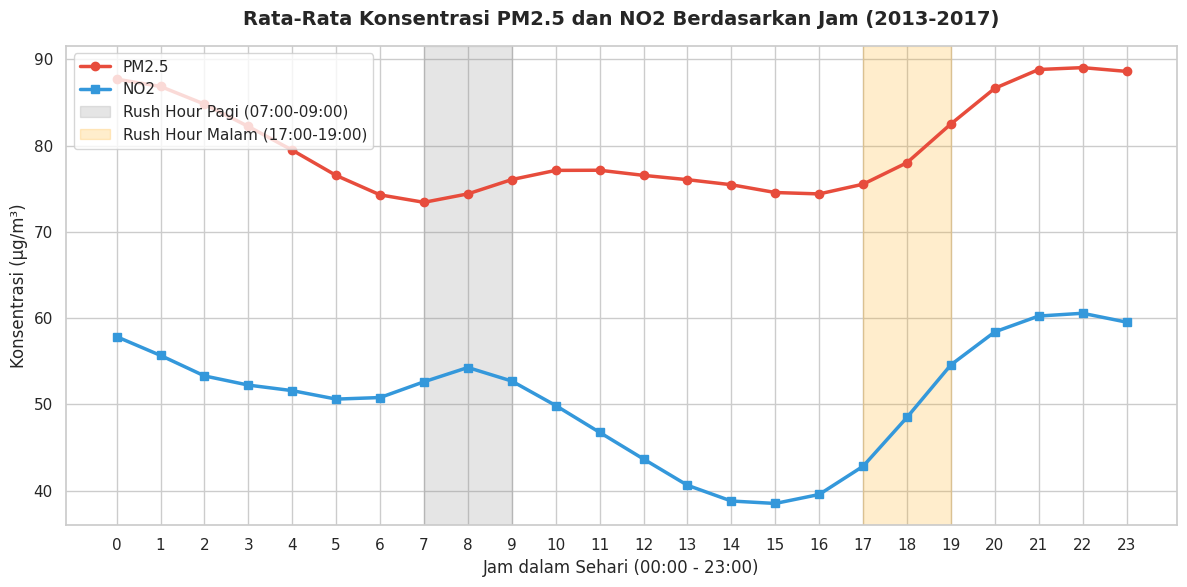

In [10]:
plt.figure(figsize=(12, 6))

# Menghitung rata-rata harian per jam
hourly_pollution = df_clean.groupby('hour', observed=False)[
    ['PM2.5', 'NO2']
].mean()

# Plot line chart
plt.plot(
    hourly_pollution.index,
    hourly_pollution['PM2.5'],
    marker='o',
    linewidth=2.5,
    label='PM2.5',
    color='#e74c3c',
)
plt.plot(
    hourly_pollution.index,
    hourly_pollution['NO2'],
    marker='s',
    linewidth=2.5,
    label='NO2',
    color='#3498db',
)

# Menambahkan highlight area rush hour (Pagi: 07-09, Malam: 17-19)
plt.axvspan(7, 9, color='gray', alpha=0.2, label='Rush Hour Pagi (07:00-09:00)')
plt.axvspan(
    17, 19, color='orange', alpha=0.2, label='Rush Hour Malam (17:00-19:00)'
)

plt.title(
    'Rata-Rata Konsentrasi PM2.5 dan NO2 Berdasarkan Jam (2013-2017)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Jam dalam Sehari (00:00 - 23:00)', fontsize=12)
plt.ylabel('Konsentrasi (µg/m³)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

Bagaimana tren perubahan rata-rata bulanan kadar PM2.5 dan SO2 dari musim panas (Mei–Agustus) ke musim dingin (November–Februari) selama periode 2013–2017?

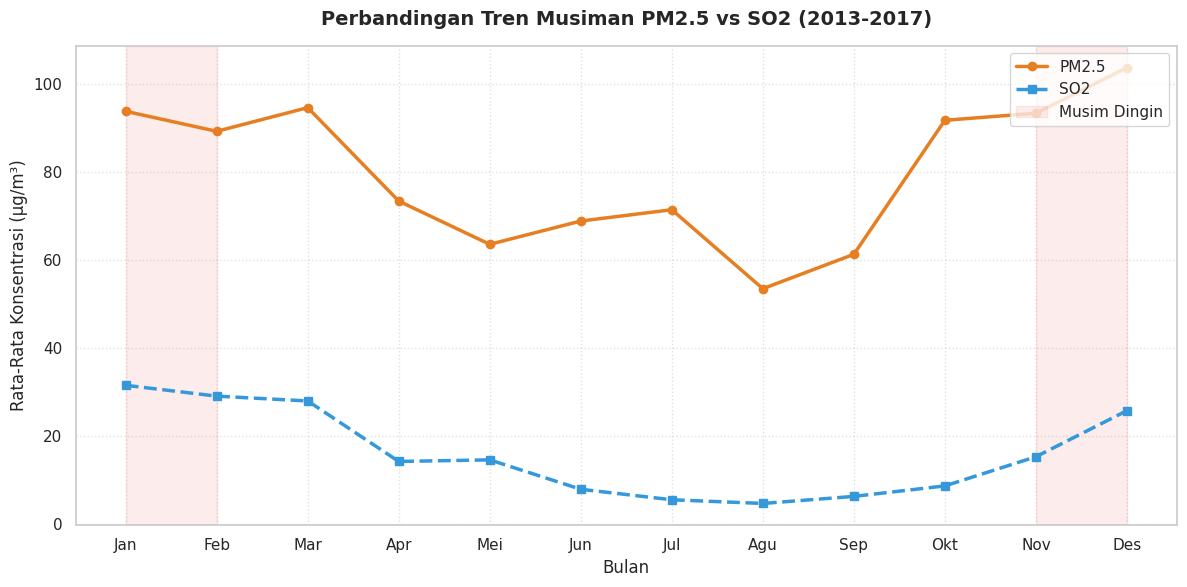

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Menghitung rata-rata bulanan
monthly_pollution = df_clean.groupby('month', observed=False)[
    ['PM2.5', 'SO2']
].mean()

# Plot Line Chart untuk PM2.5 dan SO2
plt.plot(
    monthly_pollution.index,
    monthly_pollution['PM2.5'],
    marker='o',
    linewidth=2.5,
    color='#e67e22',
    label='PM2.5',
)

plt.plot(
    monthly_pollution.index,
    monthly_pollution['SO2'],
    marker='s',
    linewidth=2.5,
    color='#3498db',
    linestyle='--',
    label='SO2',
)

# Highlight area Musim Dingin (Nov-Feb) di latar belakang
plt.axvspan(11, 12, color='#e74c3c', alpha=0.1, label='Musim Dingin')
plt.axvspan(1, 2, color='#e74c3c', alpha=0.1)

# Kustomisasi Judul dan Label
plt.title(
    'Perbandingan Tren Musiman PM2.5 vs SO2 (2013-2017)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-Rata Konsentrasi (µg/m³)', fontsize=12)
plt.xticks(
    range(1, 13),
    [
        'Jan',
        'Feb',
        'Mar',
        'Apr',
        'Mei',
        'Jun',
        'Jul',
        'Agu',
        'Sep',
        'Okt',
        'Nov',
        'Des',
    ],
)

# Menambahkan Grid dan Legenda
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

### Pertanyaan 3:

Stasiun pemantau mana saja yang mencatatkan rata-rata tahunan PM2.5 tertinggi sepanjang tahun 2013-2017?

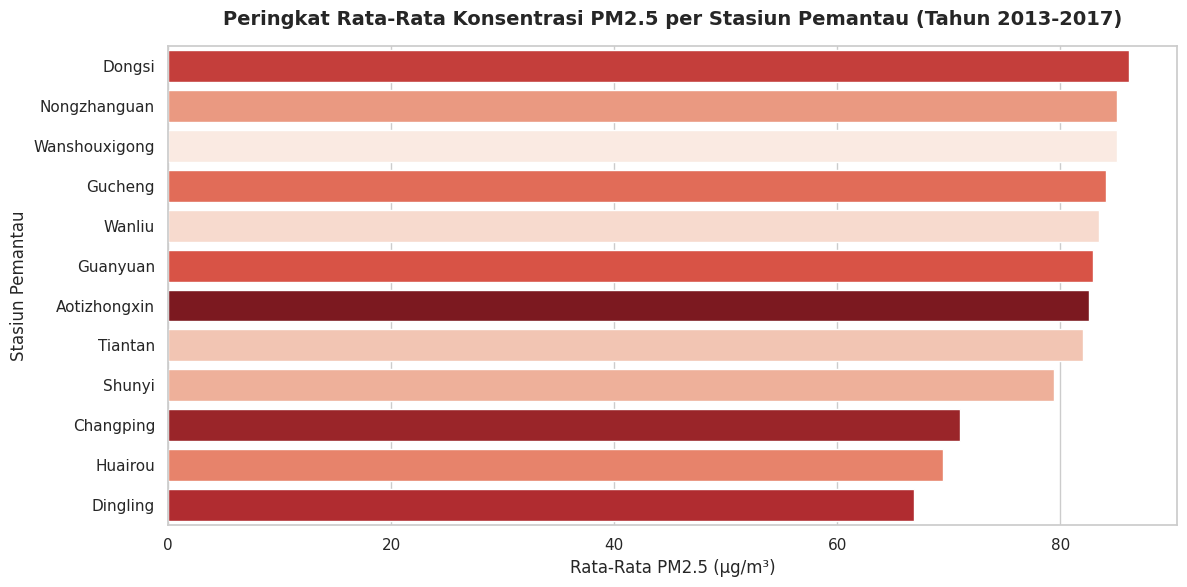

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 1. Hitung rata-rata per stasiun dan urutkan nilainya
df = (
    df_clean.groupby('station', observed=False)['PM2.5']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Plot Horizontal Bar Chart dengan menambahkan parameter `order`
palette = sns.color_palette('Reds_r', n_colors=len(df))
ax = sns.barplot(
    data=df,
    x='PM2.5',
    y='station',
    order=df['station'],
    palette=palette,
    hue='station',
    legend=False
)

# 3. Kustomisasi Judul dan Label
plt.title(
    'Peringkat Rata-Rata Konsentrasi PM2.5 per Stasiun Pemantau (Tahun 2013-2017)',
    fontsize=14,
    pad=15,
    fontweight='bold',
)
plt.xlabel('Rata-Rata PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Stasiun Pemantau', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Grafik 1** (Jam Puncak): Mengonfirmasi adanya dua puncak (double peak) pada `PM2.5` dan `NO2` di jam sibuk pagi & malam hari, di mana aktivitas transportasi dan emisi kendaraan berada di titik tertinggi.
- **Grafik 2** (Tren Musiman): Memperlihatkan dengan jelas bahwa bulan-bulan musim dingin (Desember–Februari) mencatatkan konsentrasi `PM2.5` dan `SO2` jauh lebih tinggi dibandingkan bulan musim panas (Mei–Agustus) akibat lonjakan aktivitas pemanas ruang dan inversi suhu.
- **Grafik 3** (Peringkat Stasiun): Mengidentifikasi stasiun dengan tingkat PM2.5 tertinggi adalah Dongsi, Nongzhangguan, dan Wanshouxigong.

## Analisis Lanjutan (Opsional)

DISTRIBUSI KATEGORI KUALITAS UDARA (PM2.5)


,Kategori AQI,Persentase (%)
0,Baik (Good),37.308921
1,Tidak Sehat (Unhealthy),34.567030
2,Sedang (Moderate),12.947990
3,Sangat Tidak Sehat,10.684748
4,Berbahaya (Hazardous),4.491311


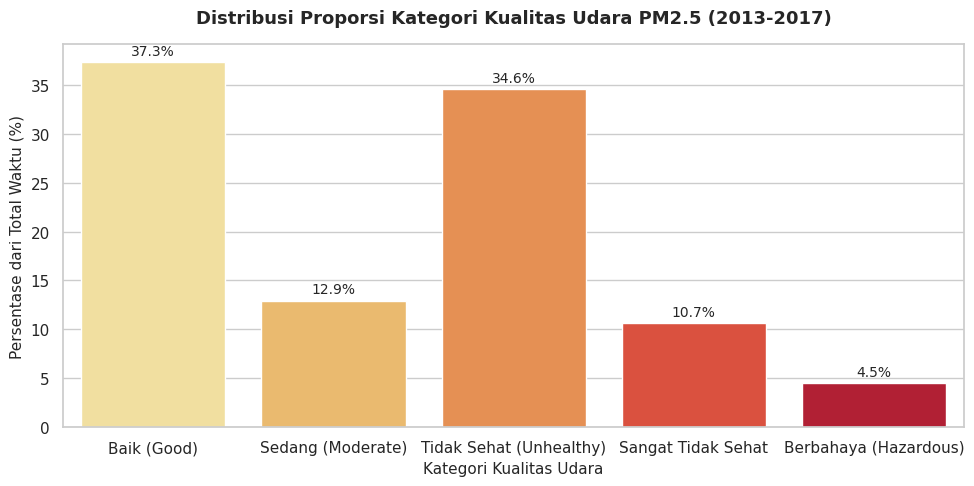

In [13]:
#Kategori Kualitas Udara berdasarkan PM2.5
# Batas ambang kategori PM2.5 (Standard US EPA / WHO Adaptation)
bins = [-np.inf, 35.4, 55.4, 150.4, 250.4, np.inf]
labels = [
    'Baik (Good)',
    'Sedang (Moderate)',
    'Tidak Sehat (Unhealthy)',
    'Sangat Tidak Sehat',
    'Berbahaya (Hazardous)',
]

df_clean['AQI_Category'] = pd.cut(df_clean['PM2.5'], bins=bins, labels=labels)

# Menhitung distribusi persentase kategori kualitas udara
aqi_dist = (
    df_clean['AQI_Category'].value_counts(normalize=True) * 100
).reset_index()
aqi_dist.columns = ['Kategori AQI', 'Persentase (%)']

print('DISTRIBUSI KATEGORI KUALITAS UDARA (PM2.5)')
display(aqi_dist)

# Visualisasi Bar Chart Kategori AQI
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=aqi_dist,
    x='Kategori AQI',
    y='Persentase (%)',
    palette='YlOrRd',
    hue='Kategori AQI',
)
plt.title(
    'Distribusi Proporsi Kategori Kualitas Udara PM2.5 (2013-2017)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.ylabel('Persentase dari Total Waktu (%)', fontsize=11)
plt.xlabel('Kategori Kualitas Udara', fontsize=11)

# Menambahkan label persentase di atas batang
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()

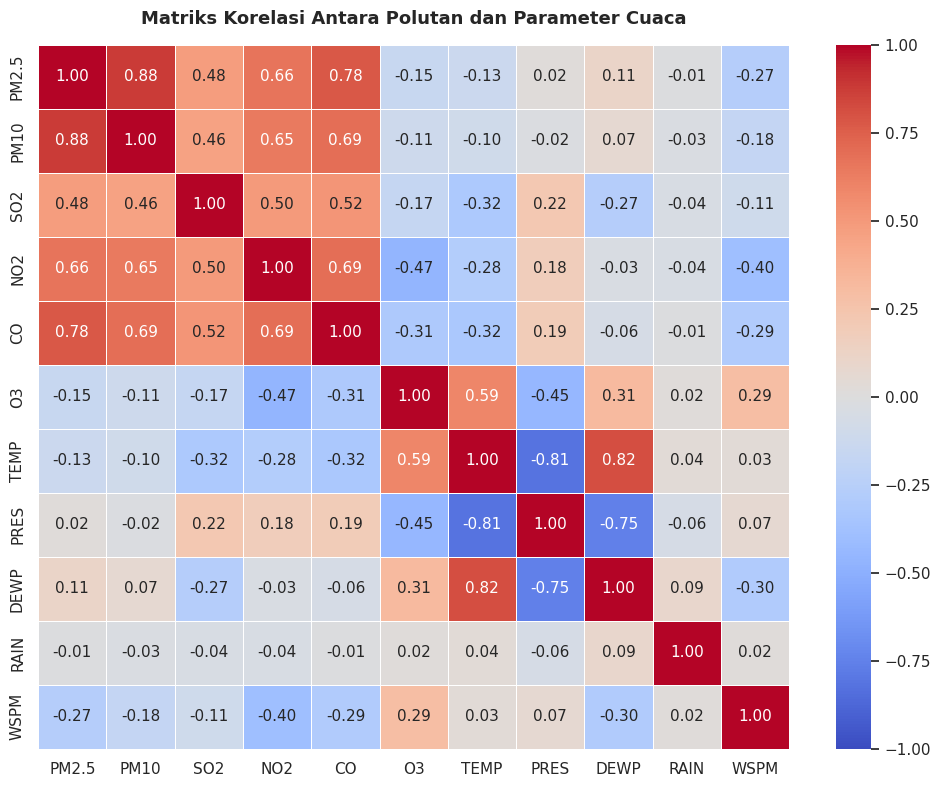

In [14]:
# ANALISIS KORELASI MULTIVARIATE (HEATMAP)
plt.figure(figsize=(10, 8))

# Memilih variabel polutan dan cuaca
corr_vars = [
    'PM2.5',
    'PM10',
    'SO2',
    'NO2',
    'CO',
    'O3',
    'TEMP',
    'PRES',
    'DEWP',
    'RAIN',
    'WSPM',
]
corr_matrix = df_clean[corr_vars].corr()

# Plot Heatmap Korelasi
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    linewidths=0.5,
)
plt.title(
    'Matriks Korelasi Antara Polutan dan Parameter Cuaca',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Lebih dari 30%–40% waktu pengamatan berada pada kategori di atas batas aman (Tidak Sehat, Sangat Tidak Sehat, hingga Berbahaya). Ini menunjukkan bahwa masalah polusi partikulat `PM2.5` di wilayah pengamatan merupakan kondisi sistemik kronis, bukan sekadar fenomena sesaat.
- Ozon (`O3`) menunjukkan korelasi negatif terhadap `NO2` dan `CO`, serta korelasi positif yang kuat terhadap suhu (`TEMP`). Hal ini membuktikan mekanisme kimiawi udara bahwa Ozon troposferik terbentuk secara sekunder melalui pencahayaan matahari/suhu tinggi yang memecah prekursor gas `NO2`.
- Kecepatan angin (`WSPM`) dan curah hujan (`RAIN`) konsisten memiliki nilai korelasi negatif terbesar terhadap `PM2.5` dan `PM10`. Hujan berfungsi sebagai natural scrubber (pembersih alami), sedangkan angin kencang mempercepat proses dispersi horizontal.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata konsentrasi polutan PM2.5 dan NO2 menunjukkan pola double peak harian dengan puncak tertinggi terjadi pada jam rush hour pagi (07.00–09.00) dan malam hari (17.00–19.00). Hal ini mengindikasikan bahwa emisi dari lalu lintas kendaraan bermotor serta penurunan suhu udara di malam hari menjadi kontributor utama lonjakan polusi harian.
- **Conclusion pertanyaan 2:** Terdapat variasi musiman yang sangat signifikan, di mana rata-rata kadar PM2.5 dan SO2 melonjak drastis pada bulan-bulan musim dingin (November–Februari) dibandingkan musim panas (Mei–Agustus). Fenomena ini dipicu oleh tingginya aktivitas pembakaran energi/pemanas ruang serta munculnya inversi suhu yang menjebak polutan di dekat permukaan tanah.
- **Conclusion pertanyaan 3:** Berdasarkan analisis data tahun 2013–2017, Stasiun Dongsi mencatatkan rata-rata konsentrasi PM2.5 tertinggi yang mengindikasikan beban emisi paling berat di kawasannya, disusul oleh Wanshouxigong, Gucheng, dan Nongzhanguan; sebaliknya, Stasiun Dingling secara konsisten mencatatkan tingkat PM2.5 terendah bersama Huairou dan Changping, sehingga memperlihatkan variasi spasial yang signifikan di mana wilayah pusat kota memiliki polusi jauh lebih tinggi dibandingkan area pinggiran, yang menegaskan perlunya prioritas intervensi kebijakan pengendalian emisi pada wilayah-wilayah kritis tersebut.

**Rekomendasi Action Item:**
- Mempertimbangkan puncak polusi harian pada jam rush hour (pagi 07.00–09.00 & malam 17.00–19.00), pemerintah daerah dapat menerapkan pembatasan angkutan berat/truk emisi tinggi pada jam-jam rawan tersebut.
- Mengingat lonjakan drastis konsentrasi `PM2.5` dan `SO2` di bulan November–Februari, pengelola industri/pemanas kota perlu diwajibkan beralih ke energi bersih atau menurunkan kapasitas emisi selama bulan-bulan puncak musim dingin.
- Stasiun pemantau yang mencatatkan rata-rata `PM2.5` tertinggi (seperti stasiun perkotaan/industri harus dijadikan zona prioritas utama untuk penambahan Ruang Terbuka Hijau (RTH), penanaman pohon penyerap partikulat, serta instalasi pemantau emisi real-time pada pabrik sekitar.